## Effective Hyeprdegree model for Regular hypergraph


This notebook genereated the solutions of the effective hyperdegree model used to create the phase diagram of SIS process in a hypegraph with regular hyperdegree distribution and uncorrelted cross-order correlation used in figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys


In [2]:
sys.path.insert(1,'../Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

In [3]:
N=1000
mu=1
k1=5
k2=3


pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)

hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

lam1=1.5
lam2=0
T=20


num_inf=100
beta1=lam1*mu/k1
beta2=lam2*mu/k2
para=[beta1,beta2,mu]


results_model_reg1=odeint_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=num_inf, steps_ode=5000)
print('')



164
-------
164
Starting ultra-optimized integration...
Progress: 54.2% (t=10.840, dt=0.010000)
Integration completed in 3417 steps



Text(0, 0.5, 'Population')

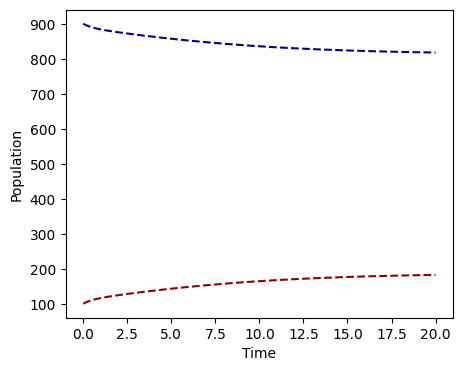

In [4]:
plt.figure(figsize=(5,4))
times,S,I=results_model_reg1

plt.plot(times,S,color='darkblue', ls='--', label='S') 
plt.plot(times,I,color='darkred', ls='--', label='I')

plt.xlabel('Time')
plt.ylabel('Population')

In [5]:
def odeint_effective_degree_HO_phase_diagram_optimized(para, lambdas, hyperedges, initial_infected=None, N=1000,T=20, steps=2000):
    
    prevalence=[]
    aux, beta2, k1, k2, gamma = para
    for i in range (len(lambdas)):
        lam1=lambdas[i]
        beta1=lam1*gamma/k1
        para=[beta1,beta2,gamma]
        times, S_t, I_t= odeint_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=initial_infected,steps_ode=steps)

        plt.show()
        prevalence.append(np.mean(I_t[-100:]))
        print('Lambda ', lam1)
        print('Prev ', prevalence[-1], times[-1])
        print('---')
        
    return prevalence

In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,3,100)
N=1000
mu=1
k1=5
k2=3

lam2=3
beta2=lam2*mu/k2


T=100


iters=100
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)


init_infec_num=[0]


pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)

hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

prevalences1=[]
para=[1,beta2,k1,k2,mu]

prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=20)
    
#minio_helper.save_file(f'Simulation_Regular_HO_alpha0/effd_N{N}_k1{k1}_k2{k2}'+f'_prev'+'.txt',pd.DataFrame(prevalence), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


/tmp/ipykernel_2690509/1177954385.py:28: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Regular_structures/reg_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_2690509/1177954385.py:29: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
    

164
-------
164
Starting ultra-optimized integration...
Progress: 3.4% (t=3.436, dt=0.003888)
Progress: 8.7% (t=8.730, dt=0.008062)
Infection died out, terminating early
Integration completed in 2918 steps


NameError: name 'plt' is not defined

In [7]:
print(prevalence1)

NameError: name 'prevalence1' is not defined

In [5]:
np.savetxt('../data/Phase_diagram/reg_prev1.txt',prevalence1)

In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,3,100)
N=1000
mu=1
k1=5
k2=3

lam2=3
beta2=lam2*mu/k2


T=60


iters=100
num_inf=900
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]

pairs= np.loadtxt(f'../data/higherorder_networkstructures/reg_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples = np.loadtxt(f'../data/higherorder_networkstructures/reg_triples_N{N}_k1{k1}_k2{k2}.txt', dtype=float).astype(int)


hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

prevalences2=[]
para=[1,beta2,k1,k2,mu]

prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=num_inf)
    
#minio_helper.save_file(f'Simulation_Regular_HO_alpha0/effd_N{N}_k1{k1}_k2{k2}'+f'_prev'+'.txt',pd.DataFrame(prevalence), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


/tmp/ipykernel_2658072/4194382600.py:26: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Regular_structures/reg_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_2658072/4194382600.py:27: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
    

164
-------
164
Starting ultra-optimized integration...
Progress: 0.4% (t=0.254, dt=0.000420)
Progress: 2.4% (t=1.450, dt=0.002600)
Progress: 7.6% (t=4.555, dt=0.003120)
Progress: 12.8% (t=7.675, dt=0.003120)
Progress: 18.6% (t=11.187, dt=0.004493)
Progress: 29.7% (t=17.839, dt=0.009316)
Infection died out, terminating early
Integration completed in 6580 steps
Lambda  0.001
Prev  1.6957206983266227e-06 23.578547359772706
---
164
-------
164
Starting ultra-optimized integration...
Progress: 0.6% (t=0.387, dt=0.000583)
Progress: 3.7% (t=2.242, dt=0.003009)
Progress: 8.8% (t=5.252, dt=0.003009)
Progress: 13.8% (t=8.261, dt=0.003009)
Progress: 21.9% (t=13.139, dt=0.006240)
Progress: 35.7% (t=21.431, dt=0.010000)
Infection died out, terminating early
Integration completed in 6283 steps
Lambda  0.031292929292929296
Prev  1.67228237757716e-06 24.260841341391487
---
164
-------
164
Starting ultra-optimized integration...
Progress: 0.4% (t=0.264, dt=0.000420)
Progress: 2.6% (t=1.552, dt=0.00312

In [37]:
print(prevalence2)

[1.7052026319127624e-06, 1.6769719469065036e-06, 1.6427834041083096e-06, 1.6147153621161466e-06, 1.594034479863581e-06, 1.5652497933386298e-06, 1.545303081887701e-06, 1.5282524587102426e-06, 1.5019232599569826e-06, 1.4825903083373861e-06, 1.4559605067865152e-06, 1.436842556526531e-06, 1.4148966963909587e-06, 1.4010943385290737e-06, 1.3801975182746716e-06, 1.3645943688336078e-06, 1.345990187670756e-06, 1.3314067000796237e-06, 1.3126548960972013e-06, 1.2953067099727875e-06, 1.2793589758923485e-06, 1.2622727678354989e-06, 2.7229621398737285e-06, 3.0278051776203805e-05, 0.0006484541290072489, 0.08540721923462742, 353.2879836126989, 470.6085664131699, 506.9890899005888, 531.6054544130992, 550.7727196910895, 566.6455603105461, 580.2658724446551, 592.2303352412471, 602.9175064144465, 612.5847992617363, 621.4162767639917, 629.5486832178894, 637.0867148622609, 644.1125077974938, 650.691810007014, 656.8781501157273, 662.7157427897628, 668.241568194106, 673.4868946783527, 678.4784160982331, 683.2

In [6]:
prevalence2 = [1.7052026319127624e-06, 1.6769719469065036e-06, 1.6427834041083096e-06, 1.6147153621161466e-06, 1.594034479863581e-06, 1.5652497933386298e-06, 1.545303081887701e-06, 1.5282524587102426e-06, 1.5019232599569826e-06, 1.4825903083373861e-06, 1.4559605067865152e-06, 1.436842556526531e-06, 1.4148966963909587e-06, 1.4010943385290737e-06, 1.3801975182746716e-06, 1.3645943688336078e-06, 1.345990187670756e-06, 1.3314067000796237e-06, 1.3126548960972013e-06, 1.2953067099727875e-06, 1.2793589758923485e-06, 1.2622727678354989e-06, 2.7229621398737285e-06, 3.0278051776203805e-05, 0.0006484541290072489, 0.08540721923462742, 353.2879836126989, 470.6085664131699, 506.9890899005888, 531.6054544130992, 550.7727196910895, 566.6455603105461, 580.2658724446551, 592.2303352412471, 602.9175064144465, 612.5847992617363, 621.4162767639917, 629.5486832178894, 637.0867148622609, 644.1125077974938, 650.691810007014, 656.8781501157273, 662.7157427897628, 668.241568194106, 673.4868946783527, 678.4784160982331, 683.2391162050864, 687.788935783657, 692.1452946549065, 696.3235051678903, 700.3371033880666, 704.1981170437539, 707.9172843011912, 711.5042338946032, 714.9676345834632, 718.3153200429016, 721.5543939124815, 724.6913186952254, 727.7319914169783, 730.6818083590136, 733.5457207161832, 736.3282826747884, 739.0336931235328, 741.6658319890868, 744.2282920113435, 746.7244066321298, 749.157274557258, 751.5297814594777, 753.8446192146538, 756.1043030018211, 758.311186546938, 760.4674757481912, 762.5752408857132, 764.6364275893766, 766.6528667139402, 768.6262832501602, 770.5583043831316, 772.4504667943351, 774.3042232913689, 776.1209488385825, 777.9019460526788, 779.6484502194845, 781.3616338812633, 783.0426110381331, 784.6924410020029, 786.3121319371329, 787.9026441174474, 789.4648929275069, 790.9997516310411, 792.5080539283755, 793.9905963218603, 795.4481403063915, 796.881414400357, 798.2911160308266, 799.6779132853692, 801.0424465417215, 802.3853299854054, 803.7071530244415, 805.0084816094641, 806.2898594667154]

In [7]:
np.savetxt('../data/Phase_diagram/reg_prev2.txt',prevalence2)